# Proyek Pertama: Menyelesaikan Permasalahan Human Resources (HR)

- Nama: Cornelius
- Email: sw.cornel@gmail.com
- Id Dicoding: cswynt

## Persiapan

### Menyiapkan library yang dibutuhkan

In [275]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import joblib

### Menyiapkan data yang akan digunakan

In [276]:
df = pd.read_csv("employee_data.csv")
df.head()

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,2,80,3,20,2,3,5,3,0,2


## Data Understanding

In [277]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1470 non-null   str    
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   str    
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   str    
 9   EmployeeCount             1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   str    
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   int64  
 14  JobLevel           

EmployeeId                    0
Age                           0
Attrition                   412
BusinessTravel                0
DailyRate                     0
Department                    0
DistanceFromHome              0
Education                     0
EducationField                0
EmployeeCount                 0
EnvironmentSatisfaction       0
Gender                        0
HourlyRate                    0
JobInvolvement                0
JobLevel                      0
JobRole                       0
JobSatisfaction               0
MaritalStatus                 0
MonthlyIncome                 0
MonthlyRate                   0
NumCompaniesWorked            0
Over18                        0
OverTime                      0
PercentSalaryHike             0
PerformanceRating             0
RelationshipSatisfaction      0
StandardHours                 0
StockOptionLevel              0
TotalWorkingYears             0
TrainingTimesLastYear         0
WorkLifeBalance               0
YearsAtC

<Axes: xlabel='MonthlyIncome'>

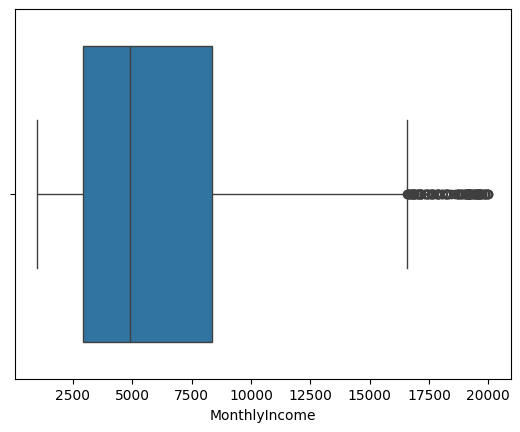

In [278]:
# cek duplicate
df.duplicated().sum()

# cek outlier (contoh)
sns.boxplot(x=df['MonthlyIncome'])

### Exploratory Data Analysis (EDA)

<Axes: xlabel='OverTime', ylabel='Attrition'>

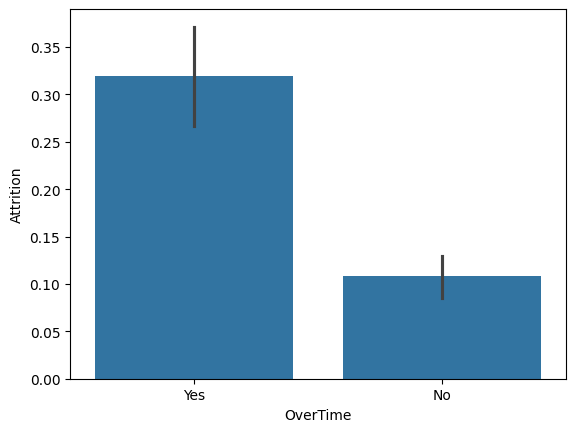

In [279]:
sns.barplot(x='OverTime', y='Attrition', data=df)

Insight:
Karyawan yang melakukan overtime memiliki tingkat attrition yang jauh lebih tinggi (~32%) dibandingkan yang tidak (~11%).

<Axes: xlabel='Attrition', ylabel='YearsAtCompany'>

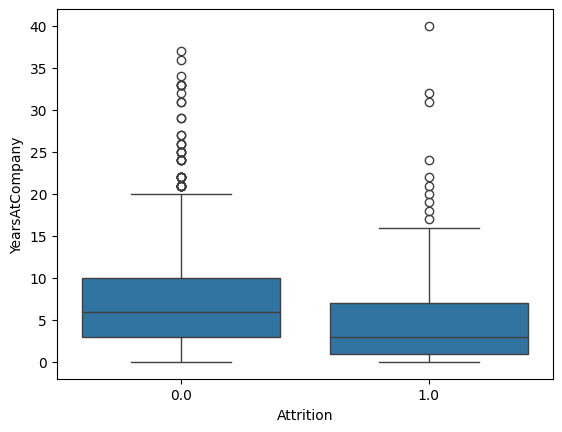

In [280]:
sns.boxplot(x='Attrition', y='YearsAtCompany', data=df)

Insight:
Karyawan dengan masa kerja pendek memiliki tingkat attrition lebih tinggi.

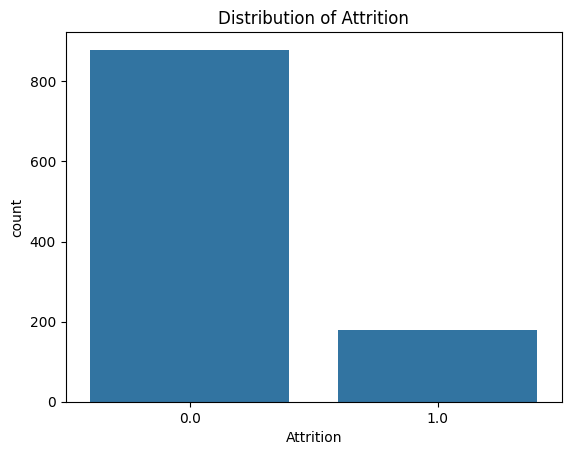

In [281]:
# Distribusi Attrition
sns.countplot(x='Attrition', data=df)
plt.title("Distribution of Attrition")
plt.show()

Insight:
Mayoritas karyawan tidak mengalami attrition (~83%), sedangkan sekitar 17% mengalami attrition.
Hal ini menunjukkan dataset cukup imbalance.

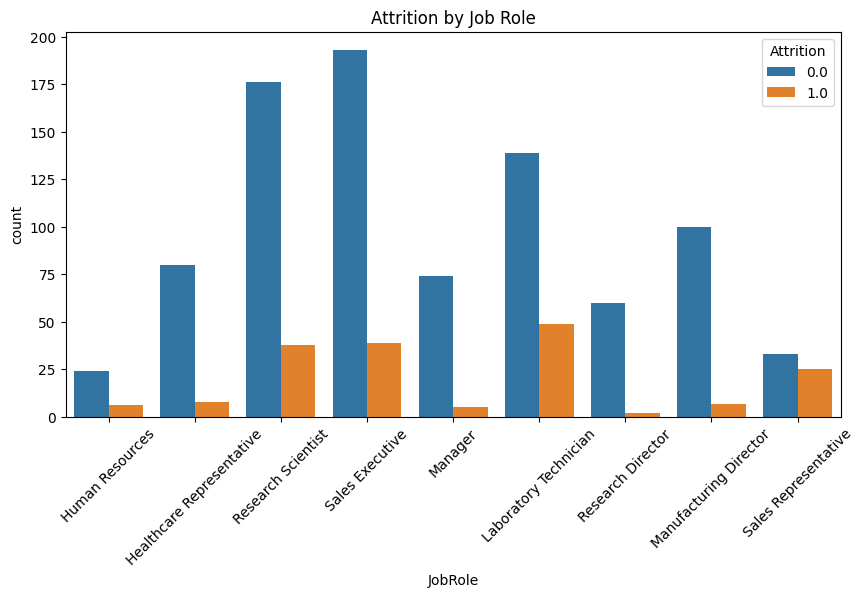

In [282]:
plt.figure(figsize=(10,5))
sns.countplot(x='JobRole', hue='Attrition', data=df)
plt.xticks(rotation=45)
plt.title("Attrition by Job Role")
plt.show()

Insight:
Beberapa job role seperti Sales Representative memiliki proporsi attrition lebih tinggi dibandingkan role lainnya.
Hal ini menunjukkan bahwa jenis pekerjaan mempengaruhi tingkat attrition.

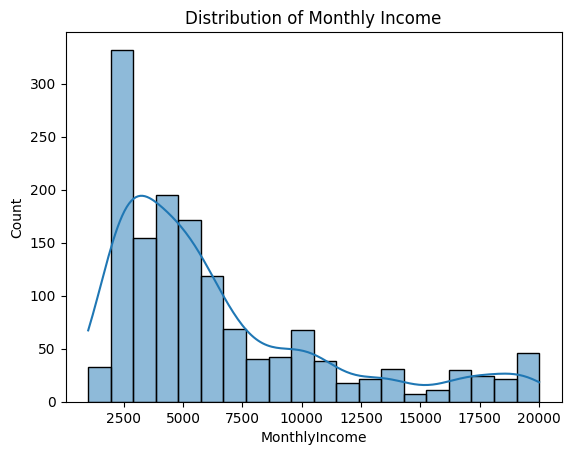

In [283]:
sns.histplot(df['MonthlyIncome'], kde=True)
plt.title("Distribution of Monthly Income")
plt.show()

Insight:
Distribusi gaji cenderung skew ke kanan, dengan sebagian besar karyawan berada di level gaji rendah hingga menengah.

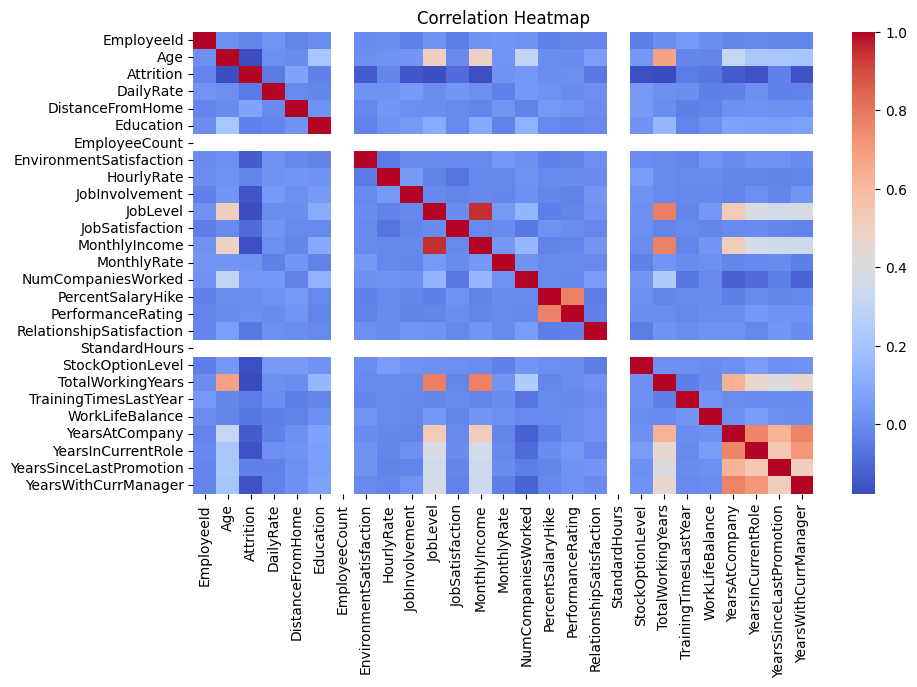

In [284]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Insight:
Tidak terdapat korelasi yang sangat kuat antar variabel, yang menunjukkan bahwa attrition dipengaruhi oleh kombinasi berbagai faktor.

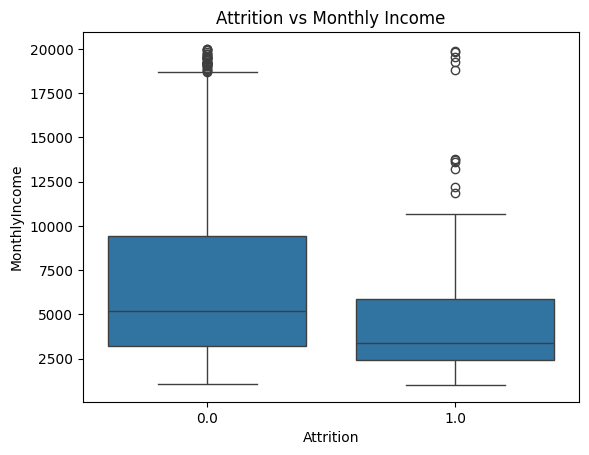

In [285]:
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title("Attrition vs Monthly Income")
plt.show()

Insight:
Karyawan dengan income lebih rendah cenderung memiliki attrition lebih tinggi.

## Data Preparation / Preprocessing

In [286]:
# drop missing target
df = df.dropna(subset=['Attrition'])

# convert ke integer
df['Attrition'] = df['Attrition'].astype(int)
print(df['Attrition'].isnull().sum())

# drop kolom tidak penting
df.drop(['EmployeeId'], axis=1, inplace=True)
df.drop(['EmployeeCount', 'Over18', 'StandardHours'], axis=1, inplace=True)

# cek distribusi target
df['Attrition'].value_counts(normalize=True)

0


Attrition
0    0.830813
1    0.169187
Name: proportion, dtype: float64

### Handling Missing Value

Kolom Attrition memiliki 412 missing values. Karena Attrition merupakan target variable, data yang tidak memiliki nilai pada kolom ini tidak dapat digunakan untuk proses modeling.

Oleh karena itu, baris data dengan nilai Attrition kosong dihapus dari dataset untuk memastikan kualitas data yang digunakan dalam analisis dan pemodelan.

In [287]:
df.to_csv("cleaned_data.csv", index=False)

<Axes: xlabel='OverTime', ylabel='Attrition'>

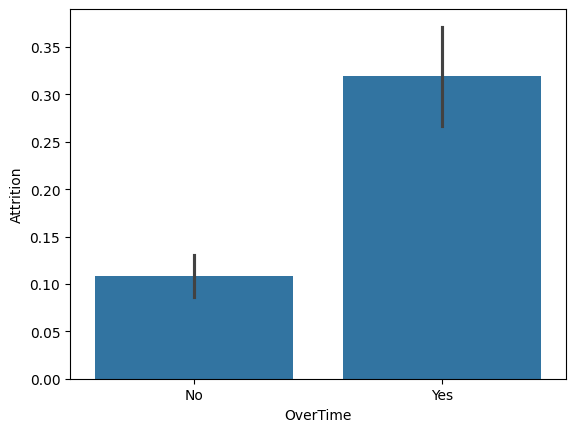

In [288]:
sns.barplot(x='OverTime', y='Attrition', data=df)

Insight:
Karyawan yang melakukan overtime memiliki tingkat attrition yang jauh lebih tinggi (~32%) dibandingkan yang tidak (~11%).

<Axes: xlabel='Attrition', ylabel='YearsAtCompany'>

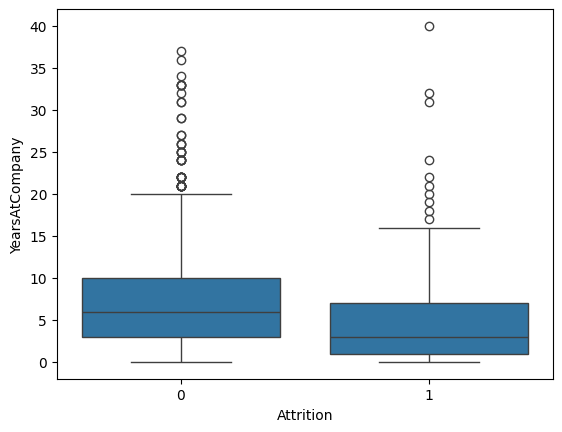

In [289]:
sns.boxplot(x='Attrition', y='YearsAtCompany', data=df)

Insight:
Karyawan dengan masa kerja pendek memiliki tingkat attrition lebih tinggi.

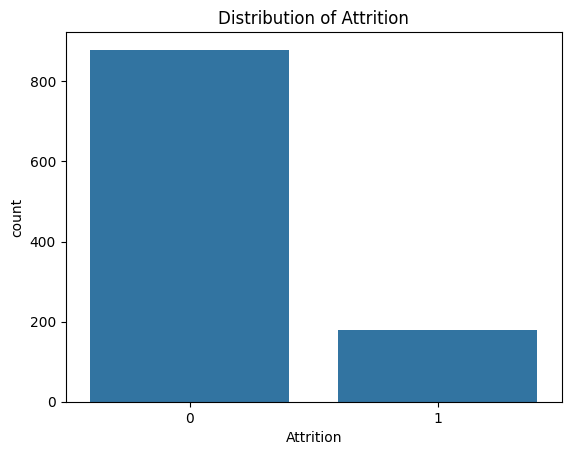

In [290]:
# Distribusi Attrition
sns.countplot(x='Attrition', data=df)
plt.title("Distribution of Attrition")
plt.show()

Insight:
Mayoritas karyawan tidak mengalami attrition (~83%), sedangkan sekitar 17% mengalami attrition.
Hal ini menunjukkan dataset cukup imbalance.

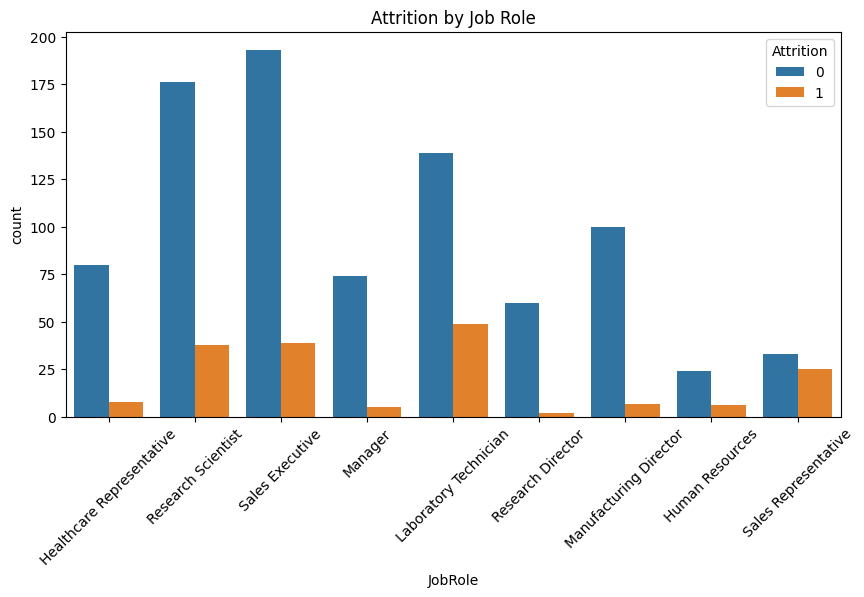

In [291]:
plt.figure(figsize=(10,5))
sns.countplot(x='JobRole', hue='Attrition', data=df)
plt.xticks(rotation=45)
plt.title("Attrition by Job Role")
plt.show()

Insight:
Beberapa job role seperti Sales Representative memiliki proporsi attrition lebih tinggi dibandingkan role lainnya.
Hal ini menunjukkan bahwa jenis pekerjaan mempengaruhi tingkat attrition.

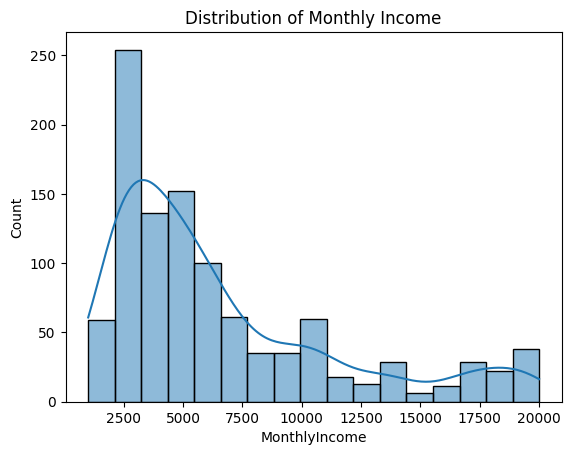

In [292]:
sns.histplot(df['MonthlyIncome'], kde=True)
plt.title("Distribution of Monthly Income")
plt.show()

Insight:
Distribusi gaji cenderung skew ke kanan, dengan sebagian besar karyawan berada di level gaji rendah hingga menengah.

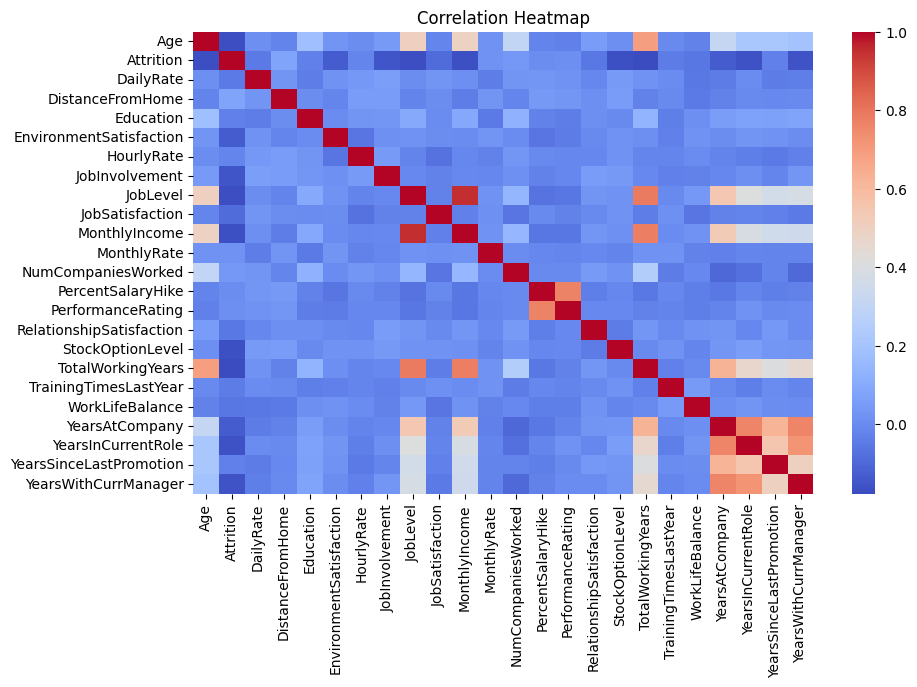

In [293]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Insight:
Tidak terdapat korelasi yang sangat kuat antar variabel, yang menunjukkan bahwa attrition dipengaruhi oleh kombinasi berbagai faktor.

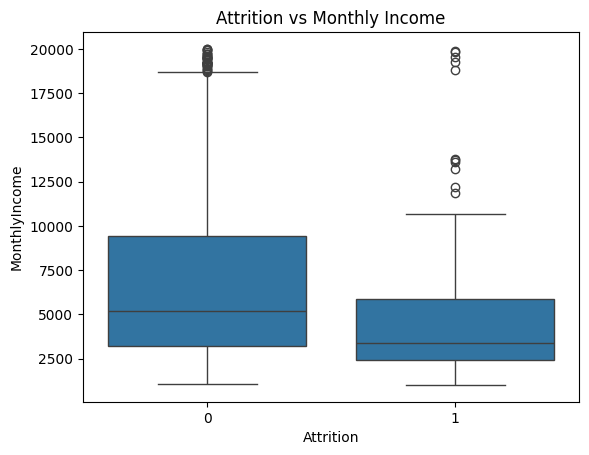

In [294]:
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title("Attrition vs Monthly Income")
plt.show()

Insight:
Karyawan dengan income lebih rendah cenderung memiliki attrition lebih tinggi.

In [295]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

X = pd.get_dummies(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Data dibagi menjadi data training dan testing untuk mengevaluasi performa model pada data yang belum pernah dilihat sebelumnya.

Data kategorikal diubah menjadi bentuk numerik menggunakan one-hot encoding (pd.get_dummies) agar dapat digunakan oleh algoritma machine learning.

In [296]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (846, 51)
Test shape: (212, 51)


## Modeling

Model yang digunakan adalah Random Forest Classifier karena mampu menangani data dengan banyak fitur serta menangkap hubungan non-linear antar variabel.

In [297]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Evaluation

In [298]:
print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.8537735849056604


In [299]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      1.00      0.92       173
           1       1.00      0.21      0.34        39

    accuracy                           0.85       212
   macro avg       0.92      0.60      0.63       212
weighted avg       0.88      0.85      0.81       212



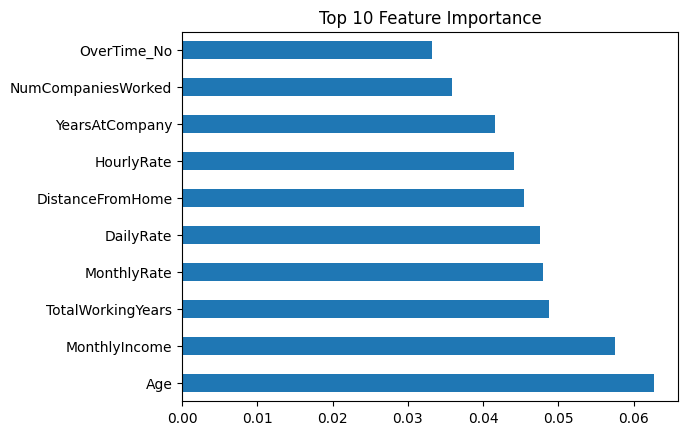

In [300]:
# Feature importance
feat_imp = pd.Series(model.feature_importances_, index=X.columns)
feat_imp.sort_values(ascending=False).head(10).plot(kind='barh')
plt.title("Top 10 Feature Importance")
plt.show()

In [301]:
# simpan model dan kolom
joblib.dump(model, 'model.pkl')
joblib.dump(X.columns.tolist(), 'columns.pkl')

['columns.pkl']